## important libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns


## Load Dataset

In [ ]:
df=pd.read_csv('train.csv')
df.head()

## EDA

Survival Distribution

In [ ]:
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution')
plt.show()

Sex vs Survival 

In [ ]:
sns.countplot(x='Sex',hue='Survived',data=df)
plt.title('Sex vs Survival')
plt.show()

## Key Statistics

In [ ]:
stats = df.groupby('Sex').agg(Total_Passengers=('Survived', 'count'),Survival_Percentage=('Survived', 'mean'))
stats['Survival_Percentage'] = (stats['Survival_Percentage'] * 100).round(2).astype(str) + '%'
print(stats)

### Observation

- Female passengers had a much higher survival rate than males
- Male passengers accounted for most fatalities
- Sex appears to be one of the strongest predictors of survival

### Business Insight

Women were more likely to survive during the evacuation process

Pclass vs Survival

In [ ]:
sns.countplot(x='Pclass',hue='Survived',data=df)
plt.title('Pclass vs Survival')
plt.show()

## Key Statistics

In [ ]:
stats = df.groupby('Pclass').agg(Total_Passengers=('Survived', 'count'),Survival_Percentage=('Survived', 'mean'))
stats['Survival_Percentage'] = (stats['Survival_Percentage'] * 100).round(2).astype(str) + '%'
print(stats)

### Observation

- First-class passengers had the highest survival rate
- Third-class passengers had the lowest survival rate
- Survival probability decreased as passenger class decreased

### Business Insight

Passengers from higher classes had better chances of survival

Age Distribution

In [ ]:
sns.histplot(df['Age'],bins=30)
plt.title('Age Distribution')
plt.show()

### Observation

- Most passengers were between 20 and 35 years old
- The age distribution is right-skewed
- Elderly passengers were relatively few

### Business Insight

The dataset is dominated by young adult passengers

Fare vs Survival

In [ ]:
sns.boxplot(y='Fare',x='Survived',data=df)
plt.title('Fare vs Survival')
plt.show()

## Key Statistics

In [ ]:
stats = df.groupby('Fare').agg(Total_Passengers=('Survived', 'count'),Survival_Percentage=('Survived', 'mean'))
stats['Survival_Percentage'] = (stats['Survival_Percentage'] * 100).round(2).astype(str) + '%'
print(stats)

### Observation

- Survivors generally paid higher fares
- Fare contains several high-value outliers
- Higher fares are associated with higher survival rates

### Business Insight

Passengers with higher socioeconomic status had better chances of survival

Family_Size vs Survival

In [ ]:
df['Family_Size']=df['SibSp']+df['Parch']+1
sns.countplot(x='Family_Size',hue='Survived',data=df)
plt.title('Family_Size vs Survival')
plt.show()

## Key Statistics

In [ ]:
stats = df.groupby('Family_Size').agg(Total_Passengers=('Survived', 'count'),Survival_Percentage=('Survived', 'mean'))
stats['Survival_Percentage'] = (stats['Survival_Percentage'] * 100).round(2).astype(str) + '%'
print(stats)

### Observation

- Small families (2–4 members) had better survival rates
- Passengers traveling alone showed lower survival rates
- Very large families had lower survival rates

### Business Insight

Family size appears to influence survival outcomes

Embarked vs Survival

In [ ]:
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Embarked vs Survival')
plt.show()

### Key Statistics


In [ ]:
stats = df.groupby('Embarked').agg(Total_Passengers=('Survived', 'count'),Survival_Percentage=('Survived', 'mean'))
stats['Survival_Percentage'] = (stats['Survival_Percentage'] * 100).round(2).astype(str) + '%'
print(stats)

### Observation

- Southampton had the highest number of passengers
- Cherbourg showed the highest survival rate
- Survival rates varied across embarkation points

### Business Insight

Embarkation point may be indirectly related to passenger class and wealth

## Handling Missing Values

In [ ]:
df.drop('Cabin', axis=1, inplace=True)
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.isna().sum()

## Encoding

In [ ]:
df=pd.get_dummies(df,columns=['Sex','Embarked'],drop_first=True)


Correlation Heatmap

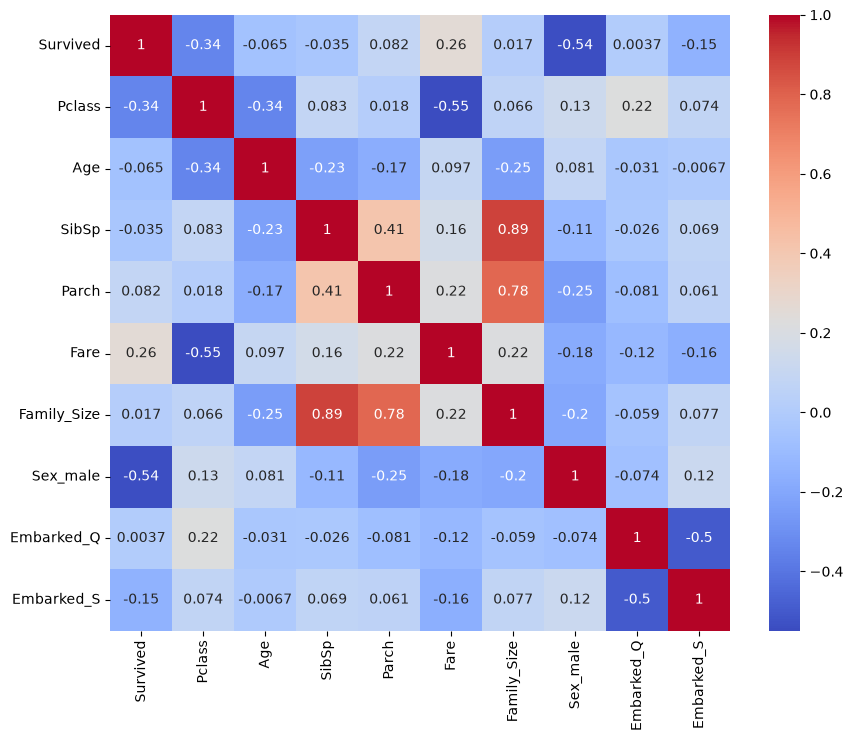

In [70]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()


### Observation

- The strongest relationship with survival is seen for male passengers (-0.54), which matches what we observed in the Sex vs Survival graph. Female passengers were much more likely to survive
- Passenger class also shows a noticeable relationship with survival (-0.34). Since 1st class is represented by a smaller number, this suggests that passengers in higher classes had better chances of survival
- Fare has a positive correlation with survival (0.26), indicating that passengers who paid higher fares were generally more likely to survive
- Age has a very weak correlation with survival (-0.06), suggesting that age alone was not a major factor in determining survival
- Family_Size shows almost no direct correlation with survival (0.02). However, different family size groups may still show useful patterns when analyzed separately
- Fare and Pclass have a strong negative correlation (-0.55), which makes sense because passengers in higher classes usually paid higher fares
- SibSp, Parch, and Family_Size are highly correlated since Family_Size was created using SibSp and Parch
### Insight

From the heatmap, Sex, Pclass, and Fare appear to be the most important features for predicting survival. This is consistent with the patterns observed in the earlier EDA graphs, making these features strong candidates for the machine learning model

## Train-Test Split

In [ ]:
X=df[['Pclass','Age','SibSp','Parch','Fare','Family_Size','Sex_male','Embarked_Q','Embarked_S']]
Y=df['Survived']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=42)
print(X_train.shape)
print(X_test.shape)

## Logistic Regression

In [ ]:
model_logistic=LogisticRegression(max_iter=1000)
model_logistic.fit(X_train,Y_train)
Y_pred=model_logistic.predict(X_test)
print(Y_pred[:10])

## Logistic Evaluation

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,confusion_matrix
print("Accuracy_score :",accuracy_score(Y_test,Y_pred))
print("Precision_score :",precision_score(Y_test,Y_pred))
print("f1_score :",f1_score(Y_test,Y_pred))
print("Recall_score :",recall_score(Y_test,Y_pred))

print("Confusion_matrix :",confusion_matrix(Y_test,Y_pred))

### Logistic Regression Results

- The model achieved an accuracy of approximately 81% on the test set
- Precision (79.4%) indicates that when the model predicts survival, it is correct most of the time
- Recall (73.0%) shows that the model successfully identified a majority of the actual survivors
- The F1 Score (76.1%) suggests a good balance between precision and recall
- Overall, the model performs reasonably well in distinguishing between survivors and non-survivors

### Insight

The model is better at identifying non-survivors than survivors. While the overall accuracy is good, some actual survivors are still being classified as non-survivors, indicating room for improvement through additional features or more advanced models

## Why Recall is Important

Recall is an important metric in this project because it measures how many actual survivors were correctly identified by the model

A low recall means that some real survivors are incorrectly classified as non-survivors (False Negatives). Therefore along with accuracy, recall was also considered while evaluating the model

## Random Forest

In [ ]:
model_rf=RandomForestClassifier(max_depth=5,n_estimators=100,random_state=42)
model_rf.fit(X_train,Y_train)
Y_pred_rf=model_rf.predict(X_test)
print(Y_pred_rf[:10])

## RF Evaluation

In [ ]:
print("Accuracy_score :",accuracy_score(Y_test,Y_pred_rf))
print("Precision_score :",precision_score(Y_test,Y_pred_rf))
print("f1_score :",f1_score(Y_test,Y_pred_rf))
print("Recall_score :",recall_score(Y_test,Y_pred_rf))
print("Confusion_matrix :",confusion_matrix(Y_test,Y_pred_rf))

## Random Forest Results

- The Random Forest model achieved an accuracy of approximately 81.3% on the test set
- Precision increased to 85.1%, meaning that when the model predicts a passenger survived it is usually correct
- However, recall dropped to 66.7%, indicating that the model missed a larger number of actual survivors
- The F1 Score of 74.7% shows a reasonable balance between precision and recall but it is slightly lower than Logistic Regression
- Overall the model makes fewer false survival predictions but misses more real survivors

## Insight

Although Random Forest achieved slightly higher accuracy than Logistic Regression, its recall is lower. Since the goal is to correctly identify as many survivors as possible, Logistic Regression performs better for this specific problem

This highlights that accuracy alone is not enough to evaluate a model. Looking at precision, recall, and F1 score provides a more complete picture of model performance

# Model Comparison

| Metric | Logistic Regression | Random Forest |
|----------|----------|----------|
| Accuracy | 80.97% | 81.34% |
| Precision | 79.41% | 85.1% |
| Recall | 72.97% | 66.67% |
| F1 Score | 76.06% | 74.75% |

## Comparison

- Random Forest achieved slightly higher accuracy and precision than Logistic Regression
- Logistic Regression achieved higher recall and F1 score
- Random Forest was more conservative in predicting survivors resulting in fewer false positives but more false negatives
- Logistic Regression identified a larger number of actual survivors

## Model Selection

In this project, recall was considered an important metric because missing an actual survivor (False Negative) is more critical than incorrectly predicting survival

Although Random Forest achieved slightly higher accuracy, Logistic Regression provided better recall and F1 score. Therefore Logistic Regression was selected as the preferred model for this problem

## Feature Importance

In [ ]:
feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': model_rf.feature_importances_})
feature_importance.sort_values(by='Importance',ascending=False)

## Feature Importance Analysis

- `Sex_male` was the most important feature with an importance score of 0.415
- `Fare`, `Age`, and `Pclass` were the next most influential features
- Family-related features (`Family_Size`, `SibSp`, and `Parch`) had a moderate impact on survival prediction
- Embarkation features (`Embarked_S` and `Embarked_Q`) contributed the least to the model's decisions
- Overall, the model relied mainly on gender, ticket fare, age, and passenger class when predicting survival

## Insight

- The feature importance results align with the exploratory data analysis performed earlier
- Gender (`Sex_male`) had the strongest influence on survival prediction, which is consistent with the observation that female passengers had significantly higher survival rates
- Ticket fare and passenger class were also important factors, suggesting that socio-economic status played a major role during evacuation
- The embarkation location had very little impact on survival, indicating that where a passenger boarded the ship was less important than factors such as gender, class, and fare

## Error Analysis

To better understand the limitations of the model an error analysis was performed. Misclassified samples were extracted and examined to identify patterns where the model failed to make correct predictions

In [ ]:
comparison = X_test.copy()
comparison['Actual'] = Y_test
comparison['Predicted'] = Y_pred
errors = comparison[comparison['Actual'] != comparison['Predicted']]
print(errors.head())
print("Total Errors:", len(errors))

## Error Statistics

 summarizes the total number of test samples and the number of incorrect predictions made by the model

In [ ]:
print("Total Test Samples:", len(X_test))
print("Wrong Predictions:", len(errors))

### Observation

- The test dataset contained 268 passengers, out of which the model made 51 incorrect predictions
- This means the model correctly classified 217 passengers and achieved an accuracy of around 81%
- Although the overall performance is good the remaining errors indicate that some passenger profiles were still difficult for the model to classify correctly

## Error Pattern Analysis

The distribution of misclassified samples was analyzed across gender, passenger class, and actual survival outcomes. This helps identify which types of passengers were more difficult for the model to classify correctly

In [ ]:
print(errors['Sex_male'].value_counts())
print(errors['Pclass'].value_counts())
print(errors['Actual'].value_counts())

### Observation

- Among the 51 misclassified passengers, 33 were male and 18 were female. This suggests that the model made more mistakes on male passengers
- Most errors occurred in Passenger Class 3 (24 cases), followed by Class 1 (20 cases), while Class 2 had the fewest errors (7 cases)
- The model incorrectly classified 30 actual survivors and 21 actual non-survivors. This shows that the model struggled slightly more with identifying passengers who survived than those who did not survive

## Misclassified Passenger Examples

A sample of misclassified passengers was examined to understand the characteristics of cases where the model struggled. These examples provide deeper insight into the model's weaknesses

In [ ]:
errors[['Pclass','Age','Fare','Sex_male','Family_Size','Actual','Predicted']].head(10)

### Observation

- Looking at the misclassified examples, several passengers had feature combinations that were not typical of the overall trends in the dataset
- For example some male passengers from higher classes with relatively high fares actually survived but the model predicted that they would not survive. Similarly a few female passengers from lower classes were predicted as survivors even though they did not survive
- These cases indicate that survival was influenced by multiple factors at the same time and not every passenger followed the common patterns learned by the model

## Insight

- The error analysis shows that the model successfully learned the major survival patterns from the Titanic dataset such as the influence of gender, passenger class, and fare
- However the model struggled with passengers whose characteristics did not follow the usual trends. Most mistakes occurred when multiple features gave conflicting signals making the final prediction more difficult
- This suggests that while Logistic Regression performs reasonably well it cannot fully capture all complex relationships present in the dataset

## Wrong Prediction Analysis

To better understand the limitations of the model, misclassified passengers were examined separately.


#### False Negatives (Actual = 1, Predicted = 0)



In [ ]:
errors[errors['Actual'] == 1].head(10)

# Observation
Many of the missed survivors were male passengers Although gender was an important factor in survival prediction some male passengers from higher classes or with relatively higher fares survived but the model still predicted them as non-survivors. This suggests that the model sometimes relied too heavily on common survival patterns and failed to capture exceptional cases

#### False Positives (Actual = 0, Predicted = 1)


In [ ]:
errors[errors['Actual'] == 0].head(10)

## Observation

Several passengers predicted as survivors were actually non-survivors. A noticeable pattern was that some female passengers and passengers from higher classes were predicted to survive because they shared characteristics commonly associated with survival However these passengers did not survive in reality leading to incorrect predictions


#### Overall Insight

The model performed well on general survival patterns but struggled with passengers whose characteristics did not follow the usual trends Most errors occurred in cases where multiple factors gave conflicting signals such as male passengers with high fares or higher-class passengers who still did not survive This indicates that survival decisions on the Titanic were influenced by factors beyond the features available in the dataset

## Conclusion

- In this project the Titanic dataset was analyzed to identify the factors that influenced passenger survival Data cleaning, missing value handling, feature engineering, and exploratory data analysis were performed to better understand the dataset

- Two machine learning models Logistic Regression and Random Forest were trained and evaluated Logistic Regression achieved better recall while Random Forest achieved slightly higher precision. Since identifying actual survivors was considered important in this project Logistic Regression was selected as the preferred model

- Feature importance, correlation analysis and error analysis were also performed to understand model behavior beyond accuracy. The analysis showed that factors such as gender passenger class and fare played a significant role in survival prediction

- Overall, this project provided practical experience in data preprocessing, exploratory data analysis, machine learning model development, evaluation, and interpretation of results 

In [ ]:
print("Project Completed Successfully")